### Prepare the Data

#### Get data from CSV file

In [7]:
import pandas as pd
import json

In [148]:
csv_file = 'gpt-4o-mini-llm-trace-full-2-eps-base-updated.csv'

df = pd.read_csv(csv_file)
df

,observation,action_class,target_host,reason
0,# OBSERVATION\n\nMission Phase: 2\nLast Action...,Sleep,NaN,The last action is still in progress and I can...
1,# OBSERVATION\n\nMission Phase: 2\nLast Action...,Sleep,NaN,"The last action is still in progress, and ther..."
2,# OBSERVATION\n\nMission Phase: 2\nLast Action...,Sleep,NaN,"The last action is still in progress, so no fu..."
3,# OBSERVATION\n\nMission Phase: 2\nLast Action...,Analyse,host:public_access_zone_subnet_user_host_0,"Suspicious activity detected on the host, indi..."
4,# OBSERVATION\n\nMission Phase: 2\nLast Action...,Sleep,NaN,"The last action is still in progress, so I wil..."
...,...,...,...,...
995,# OBSERVATION\n\nMission Phase: 0\nLast Action...,Sleep,NaN,"Last action status is unknown, indicating that..."
996,# OBSERVATION\n\nMission Phase: 0\nLast Action...,Sleep,NaN,"Last action is in progress, waiting for action..."
997,# OBSERVATION\n\nMission Phase: 0\nLast Action...,Sleep,NaN,No suspicious activity detected; it's safe to ...
998,# OBSERVATION\n\nMission Phase: 0\nLast Action...,Sleep,NaN,Last action is still in progress.


In [152]:
df["action_class"]

0        Sleep
1        Sleep
2        Sleep
3      Analyse
4        Sleep
        ...   
995      Sleep
996      Sleep
997      Sleep
998      Sleep
999     Remove
Name: action_class, Length: 1000, dtype: object

In [151]:
df["reason"]

0      The last action is still in progress and I can...
1      The last action is still in progress, and ther...
2      The last action is still in progress, so no fu...
3      Suspicious activity detected on the host, indi...
4      The last action is still in progress, so I wil...
                             ...                        
995    Last action status is unknown, indicating that...
996    Last action is in progress, waiting for action...
997    No suspicious activity detected; it's safe to ...
998                    Last action is still in progress.
999    Multiple suspicious activities detected, indic...
Name: reason, Length: 1000, dtype: object

In [153]:
response_file = "responses_4o_mini_base_updated.txt"

# Group reasons by action_class and convert to a dictionary
responses = [{"action": row["action_class"], "reason": row["reason"]} for _, row in df.iterrows()]

with open(response_file, "a") as outfile:
    for action_reason in responses:
        outfile.write(json.dumps(action_reason) + "\n")

In [154]:
responses_dict = {}

for action_reason in responses:
    action = action_reason["action"]
    reason = action_reason["reason"]
    if reason in responses_dict and action != responses_dict[reason]:
        print("got the same reason with different actions")
    else:
        responses_dict[reason] = action

responses_dict

{'The last action is still in progress and I cannot execute further actions.': 'Sleep',
 'The last action is still in progress, and there are no suspicious activities detected.': 'Sleep',
 'The last action is still in progress, so no further actions can be taken at this time.': 'Sleep',
 'Suspicious activity detected on the host, indicating potential red agent presence.': 'Analyse',
 'The last action is still in progress, so I will remain in a sleep state until further updates.': 'Sleep',
 'The last action is still in progress and requires additional time to complete.': 'Sleep',
 'The last action is in progress and needs to be completed before taking further action.': 'Sleep',
 'Last action status is UNKNOWN, indicating the prior action is still in progress.': 'Sleep',
 'Last action status is UNKNOWN, indicating ongoing operations.': 'Sleep',
 'The last action is still in progress, and I need to wait for it to complete before taking further action.': 'Sleep',
 'The last action status i

#### OpenAI Embeddings

In [155]:
len(responses)

1000

In [156]:
%pip install openai -q

Note: you may need to restart the kernel to use updated packages.


In [157]:
### if running this on google colab:
# from google.colab import userdata
# OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

### if running this on your local machine:
### Note that you need to create a `.env` file in the same directory as this notebook and add the following line:
### OPENAI_API_KEY="your-api-key"
import os
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
# OPENAI_API_KEY

In [158]:
reasons = []
for response in responses:
    reasons.append(response["reason"])
    # print(response["action"])
    # print(response["reason"])
    # print()

In [159]:
##### save embeddings to file to save API call costs
pkl_path = "embeddings_gpt_4o_mini_base_updated.pkl"
json_path = "embeddings_gpt_4o_mini_base_updated.json"

In [160]:
import pickle

def load_embeddings_pkl(pkl_path):
    with open(pkl_path, "rb") as f:
        embeddings = pickle.load(f)
    return embeddings

def save_embeddings_pkl(embeddings, pkl_path):
    with open(pkl_path, "wb") as f:
        pickle.dump(embeddings, f)

def save_embeddings_json(embeddings, json_path):
    with open(json_path, "w") as f:
        json.dump(embeddings, f)

In [161]:
import os
from openai import OpenAI

openai = OpenAI(api_key=OPENAI_API_KEY)

if os.path.exists(pkl_path):
    print("Loading embeddings from file", pkl_path)
    embeddings = load_embeddings_pkl(pkl_path)
    print("Finished loading embeddings")

else:
    print("Generating embeddings...")
    embeddings = {}
    for reason in reasons:
        response = openai.embeddings.create(input=reason, model="text-embedding-3-large")
        embeddings[reason] = response.data[0].embedding
    print("Finished generating embeddings")

    print("Saving embeddings to file", pkl_path)
    save_embeddings_pkl(embeddings, pkl_path)
    print("Finished saving embeddings")

    print("Saving embeddings to file", json_path)
    save_embeddings_json(embeddings, json_path)
    print("Finished saving embeddings")

Generating embeddings...
Finished generating embeddings
Saving embeddings to file embeddings_gpt_4o_mini_base_updated.pkl
Finished saving embeddings
Saving embeddings to file embeddings_gpt_4o_mini_base_updated.json
Finished saving embeddings


#### Convert Embeddings to np array

In [162]:
%pip install numpy scikit-learn matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [163]:
embeddings.keys()

dict_keys(['The last action is still in progress and I cannot execute further actions.', 'The last action is still in progress, and there are no suspicious activities detected.', 'The last action is still in progress, so no further actions can be taken at this time.', 'Suspicious activity detected on the host, indicating potential red agent presence.', 'The last action is still in progress, so I will remain in a sleep state until further updates.', 'The last action is still in progress and requires additional time to complete.', 'The last action is in progress and needs to be completed before taking further action.', 'Last action status is UNKNOWN, indicating the prior action is still in progress.', 'Last action status is UNKNOWN, indicating ongoing operations.', 'The last action is still in progress, and I need to wait for it to complete before taking further action.', 'The last action status is unknown, indicating ongoing activities that require monitoring.', 'The last action is stil

In [164]:
import numpy as np

embeddings = load_embeddings_pkl(pkl_path)
X = np.array(list(embeddings.values()))
X

array([[-0.02095585,  0.00796565, -0.01436163, ...,  0.00216436,
        -0.01046174, -0.01977455],
       [ 0.01476504,  0.01555691, -0.00282515, ...,  0.00223332,
        -0.01060773, -0.02154541],
       [-0.02969932,  0.00091677, -0.00334756, ...,  0.00182735,
        -0.01390146, -0.01807355],
       ...,
       [-0.0268852 ,  0.01018198, -0.01333193, ..., -0.00853465,
        -0.01381719, -0.01370651],
       [ 0.01381033,  0.03036409, -0.00085415, ..., -0.00045883,
         0.00024145, -0.01274344],
       [-0.02903555, -0.02648586,  0.00492554, ...,  0.00134342,
         0.00530413, -0.00479805]], shape=(716, 3072))

### Clusters


##### Helper Functions


In [173]:
#### use openai to generate a summary of the clusters
def summarizeCluster(text):
    prompt = f"Summarize the main theme of the following security-related text cluster in one sentence:\n\n{'; '.join(text)}"
    response = openai.chat.completions.create(
        model="gpt-4o", 
        messages=[{"role": "system", "content": prompt}]
    )
    return response.choices[0].message.content

In [174]:
def analyzeClusters(clustered_data_map, analysis_report_path):
    with open(analysis_report_path, "w") as f:
        for cluster_num, cluster_examples in clustered_data_map.items():
            f.write(f"Cluster {cluster_num} summary:\n")
            f.write(summarizeCluster(cluster_examples))
            f.write("\n\n")

In [175]:
def getClusterActionCounter(clustered_data_map):
    cluster_action_counter = [] # checks how many actions are in the cluster (what's the majority action in the cluster)
    actions = set()

    for cluster_texts in clustered_data_map.values():
        action_counter = {}
        for cluster_text in cluster_texts:
            action = responses_dict[cluster_text]
            actions.add(action)
            if action in action_counter:
                action_counter[action] += 1
            else:
                action_counter[action] = 1
        cluster_action_counter.append(action_counter)

    return cluster_action_counter, actions

In [176]:
def saveClusterActionsToFile(label_tag, column_width, cluster_keys, cluster_action_counter, actions, output_file_path):
    with open(output_file_path, "w") as f:
        f.write(f"{label_tag}\n\n")  # Title with an extra line for spacing

        # Write the header row with center-aligned columns
        header = f"{'| Cluster #  ':^10}"  # Center-align "Cluster #"
        for action in actions:
            header += f"| {action:^{column_width}}"
        header += "|\n"  # Close the last column
        f.write(header)

        # Write a separator line
        f.write("-" * (10 + (len(actions) * (column_width + 3))) + "\n")  # Dynamic width based on actions

        # Write each cluster's data with center-aligned values
        for i in range(len(cluster_action_counter)):
            row = f'| {cluster_keys[i]:^10} '  # Center-align Cluster ID
            for action in actions:
                count = cluster_action_counter[i].get(action, 0)  # Get count, default to 0
                row += f"| {count:^{column_width}}"
            row += "|\n"  # Close the last column properly
            f.write(row)

    print(f"Cluster action results successfully written to {output_file_path}")


#### Standarize Embeddings

In [177]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Standardize the embeddings (mean=0, variance=1)
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(X)
embeddings_scaled.shape

(716, 3072)

In [178]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check if embeddings are properly standardized
feature_means = np.mean(embeddings_scaled, axis=0)
feature_stds = np.std(embeddings_scaled, axis=0)

# Print first 10 feature stats
print("Feature Means:", feature_means[:10]) # should be ~0
print("Feature Standard Deviations:", feature_stds[:10]) # should be ~1

Feature Means: [-6.79158778e-17  3.03915800e-17  1.66223336e-16 -8.55926131e-17
 -5.30302059e-17 -1.12262775e-16 -1.42654355e-17 -2.99574146e-16
 -2.82207529e-17  5.89224510e-18]
Feature Standard Deviations: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


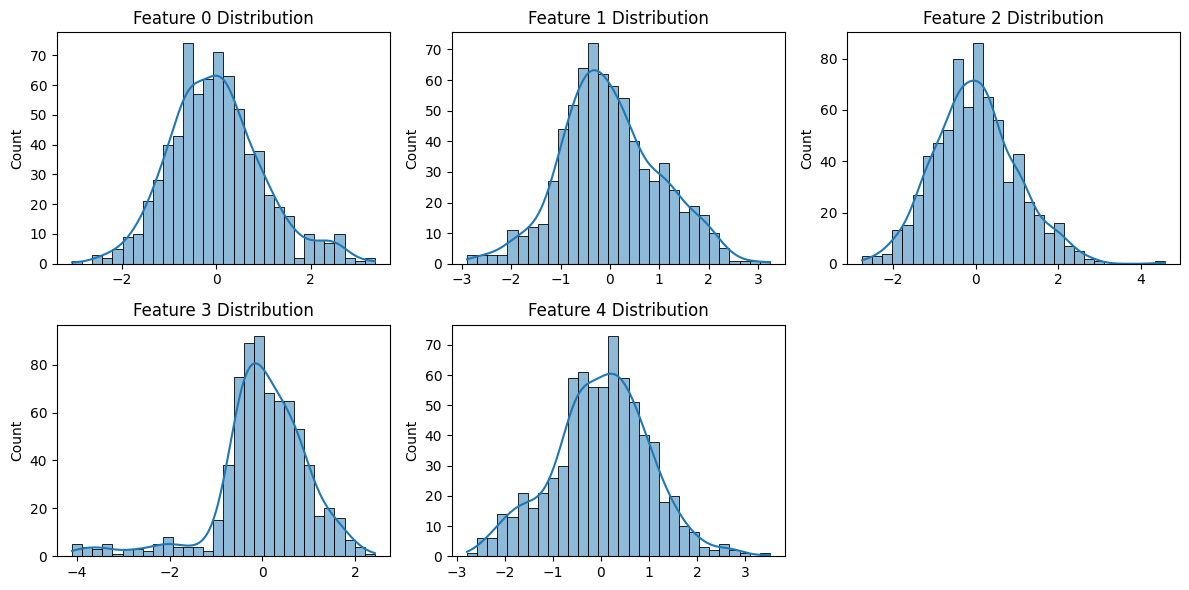

In [179]:
# Plot distributions of first 5 features
num_features = min(embeddings_scaled.shape[1], 5)  # Limit to 5 for visualization

plt.figure(figsize=(12, 6))
for i in range(num_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(embeddings_scaled[:, i], kde=True, bins=30)
    plt.title(f"Feature {i} Distribution")

plt.tight_layout()
plt.show()

#### K-means

In [180]:
%mkdir kmeans

mkdir: kmeans: File exists


In [182]:
kmeans_folder_path = "kmeans-4o-mini-base-updated/"

##### Find optimal K

In [183]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Define the range of k values to test
k_values = range(2, 15)
inertia_values = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(embeddings_scaled)
    
    # Store inertia (Elbow Method)
    inertia_values.append(kmeans.inertia_)
    
    # Compute silhouette score
    silhouette_avg = silhouette_score(embeddings_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

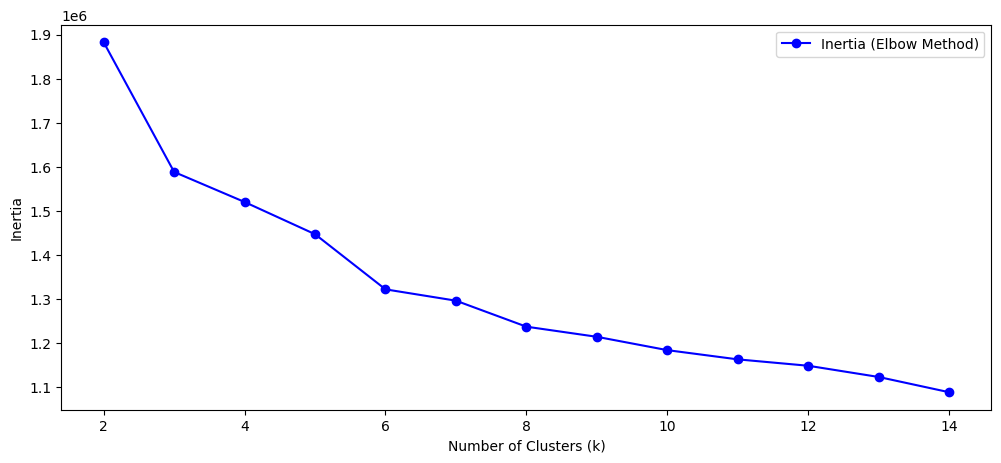

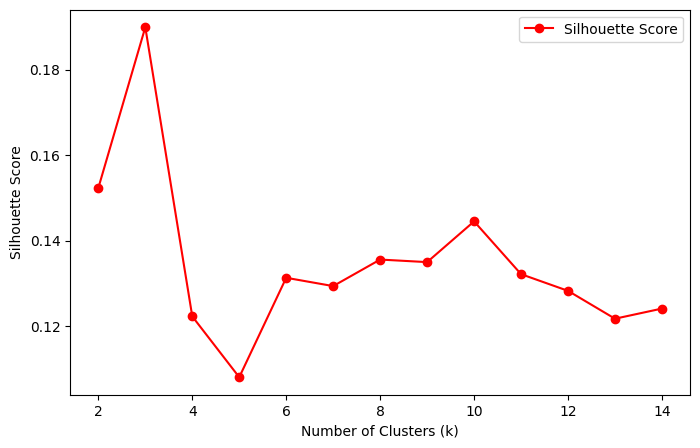

In [184]:
kmeans_elbow_method_figure_name = kmeans_folder_path + "kmeans-elbow-method.pdf"
kmeans_silhouette_score_figure_name = kmeans_folder_path + "kmeans-silhouette-score.pdf"

plt.figure(figsize=(12, 5))
plt.plot(k_values, inertia_values, 'bo-', label='Inertia (Elbow Method)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
# plt.title('Elbow Method for Optimal k')
plt.legend()
plt.savefig(kmeans_elbow_method_figure_name, format="pdf")
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, 'ro-', label='Silhouette Score')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
# plt.title("Silhouette Score for Different k Values")
plt.legend()
plt.savefig(kmeans_silhouette_score_figure_name, format="pdf")
plt.show()

In [185]:
optimal_k_silhouette = k_values[np.argmax(silhouette_scores)]
print(f"Optimal k (Silhouette Score): {optimal_k_silhouette}")
#### from the graph we see that sharp drop in inertia at k=3, and the silhouette score has a sharp drop at k=3 as well, it seems that k=3 is most optimal

Optimal k (Silhouette Score): 3


##### Run K-means with the optimal K

In [231]:
K_CLUSTERS = 6

In [232]:
# Run K-Means with the optimal number of clusters
kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=0, n_init="auto").fit(embeddings_scaled)

# Get labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

Cluster 0: 192 data points
Cluster 1: 149 data points
Cluster 2: 49 data points
Cluster 3: 135 data points
Cluster 4: 61 data points
Cluster 5: 130 data points


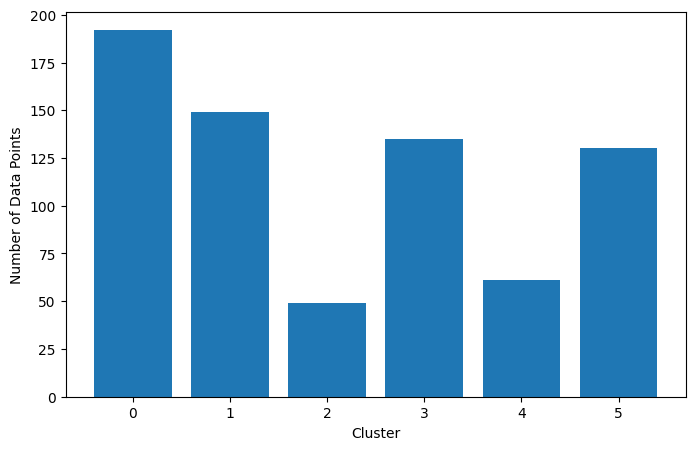

In [233]:
import numpy as np
import matplotlib.pyplot as plt

figure_name = kmeans_folder_path + "kmeans-cluster-size-distribution-" + str(K_CLUSTERS) + ".pdf"

# Count occurrences of each label
unique_labels, counts = np.unique(kmeans.labels_, return_counts=True)

# Print counts
for label, count in zip(unique_labels, counts):
    print(f"Cluster {label}: {count} data points")

# Create figure explicitly
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bar chart of cluster sizes
ax.bar(unique_labels, counts)
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Data Points")
# ax.set_title("Cluster Size Distribution")

# Save as SVG (scalable vector format)
fig.savefig(figure_name, format="pdf")  # Save before plt.show()

# Show the figure
plt.show()


##### Save Clustered Data

In [234]:
# Map cluster labels to data
clustered_data_map_kmeans = {}

for i, label in enumerate(labels):
    label = int(label)
    if label not in clustered_data_map_kmeans:
        clustered_data_map_kmeans[label] = []
    clustered_data_map_kmeans[label].append(reasons[i])
    
for key, value in clustered_data_map_kmeans.items():
    print(key, len(value))

1 149
4 61
2 49
5 130
0 192
3 135


In [235]:
# Print unique cluster counts from KMeans
unique_labels, counts = np.unique(kmeans.labels_, return_counts=True)
print("Counts from np.unique():")
for label, count in zip(unique_labels, counts):
    print(f"Cluster {label}: {count} data points")

# Print manual dictionary counts
print("\nCounts from clustered_data_map_kmeans:")
for key, value in clustered_data_map_kmeans.items():
    print(f"Cluster {key}: {len(value)} data points")

Counts from np.unique():
Cluster 0: 192 data points
Cluster 1: 149 data points
Cluster 2: 49 data points
Cluster 3: 135 data points
Cluster 4: 61 data points
Cluster 5: 130 data points

Counts from clustered_data_map_kmeans:
Cluster 1: 149 data points
Cluster 4: 61 data points
Cluster 2: 49 data points
Cluster 5: 130 data points
Cluster 0: 192 data points
Cluster 3: 135 data points


In [236]:
output_file_kmeans = kmeans_folder_path + "kmeans_clusters-" + str(K_CLUSTERS) + ".txt"

with open(output_file_kmeans, "w") as f:
    for cluster_label, cluster_texts in clustered_data_map_kmeans.items():
        f.write(f"Cluster {cluster_label}:\n")
        for cluster_text in cluster_texts:
            action = responses_dict[cluster_text]
            f.write(f"- {action}: {cluster_text}\n")
        f.write("\n")

print(f"Clustered data saved to {output_file_kmeans}.")

Clustered data saved to kmeans-4o-mini-base-updated/kmeans_clusters-6.txt.


##### Plot graphs for the Cluster

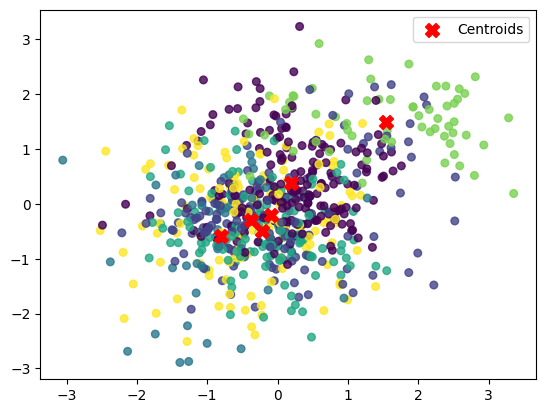

In [237]:
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots()

figure_name = kmeans_folder_path + "kmeans-cluster-2d-plot-" + str(K_CLUSTERS) + ".pdf"

# Plot clusters
sc = ax.scatter(embeddings_scaled[:, 0], embeddings_scaled[:, 1], c=labels, cmap='viridis', s=30, alpha=0.8)
ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=100, label='Centroids')

# Add title and legend
# ax.set_title("K-Means Clustering Results")
ax.legend()

# Save as SVG (scalable vector format)
fig.savefig(figure_name, format="pdf")  # Save before plt.show()

# Show the figure
plt.show()

In [238]:
from sklearn.decomposition import PCA

# Reduce dimensions for visualization
pca = PCA(n_components=3)
X_pca = pca.fit_transform(embeddings_scaled)

# Apply PCA to centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)  

In [239]:
print("Shape of X_pca:", X_pca.shape)  # Should be (num_samples, 3)
print("Shape of centroids_pca:", centroids_pca.shape)  # Should be (num_clusters, 3)
print("Unique clusters in labels:", np.unique(labels))  # Should match KMeans clusters


Shape of X_pca: (716, 3)
Shape of centroids_pca: (6, 3)
Unique clusters in labels: [0 1 2 3 4 5]


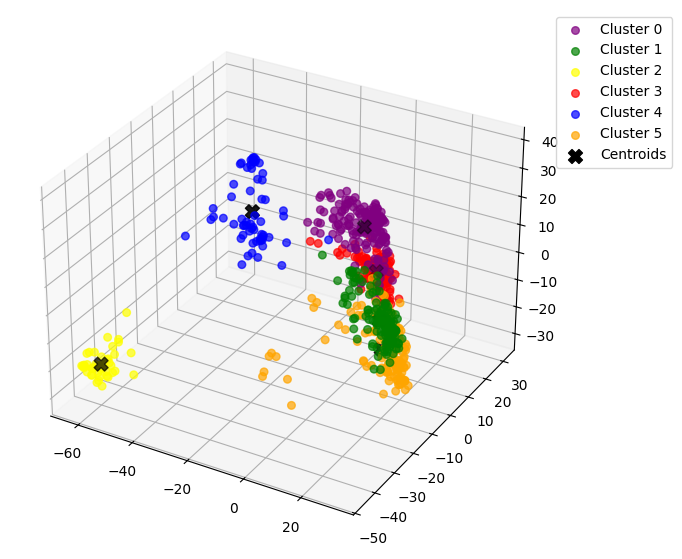

In [240]:
import numpy as np
import matplotlib.pyplot as plt

# Define cluster colors and labels
cluster_colors = {0: 'purple', 1: 'green', 2: 'yellow', 3: 'red', 4: 'blue', 5: 'orange'}
cluster_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3', 4: 'Cluster 4', 5: 'Cluster 5'}

# Initialize 3D plot
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

figure_name = kmeans_folder_path + "kmeans-cluster-3d-plot-" + str(K_CLUSTERS) + ".pdf"

# Scatter plot for each cluster
for cluster_id in np.unique(labels):
    cluster_points = X_pca[np.where(labels == cluster_id)]  # Ensure correct slicing
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], 
               c=cluster_colors[cluster_id], label=cluster_labels[cluster_id], alpha=0.7, s=30)

# Scatter plot for centroids (make them more visible)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], centroids_pca[:, 2], 
           c='black', marker='X', s=100, edgecolors='black', label='Centroids')

# Improve visibility
# ax.view_init(elev=25, azim=130)  # Adjust azim for better separation


# Set labels
# ax.set_title(f"K-Means Clustering (k={K_CLUSTERS}) - 3D PCA Projection")

# Show legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

fig.savefig(figure_name, format="pdf", bbox_inches="tight") 
# Show plot
plt.show()

##### Analyze clusters

In [241]:
cluster_action_counter_kmeans, actions_kmeans = getClusterActionCounter(clustered_data_map_kmeans)

print(clustered_data_map_kmeans.keys())
print(cluster_action_counter_kmeans)
print(actions_kmeans)

dict_keys([1, 4, 2, 5, 0, 3])
[{'Sleep': 139, 'Analyse': 10}, {'Sleep': 56, 'Analyse': 3, 'Remove': 2}, {'Analyse': 5, 'Sleep': 44}, {'Sleep': 123, 'Analyse': 7}, {'Sleep': 177, 'Analyse': 14, 'Remove': 1}, {'Sleep': 127, 'Remove': 1, 'Analyse': 7}]
{'Sleep', 'Analyse', 'Remove'}


In [242]:
column_width = 17  
output_file_path_kmeans = kmeans_folder_path + "kmeans_cluster_actions-" + str(K_CLUSTERS) + ".txt"
label_tag = kmeans_folder_path + "Kmeans Cluster Actions"
cluster_keys = list(clustered_data_map_kmeans.keys())
saveClusterActionsToFile(label_tag, column_width, cluster_keys, cluster_action_counter_kmeans, actions_kmeans, output_file_path_kmeans)

Cluster action results successfully written to kmeans-4o-mini-base-updated/kmeans_cluster_actions-6.txt


In [243]:
kmeans_analysis_report_path = kmeans_folder_path + "kmeans_analysis_report-" + str(K_CLUSTERS) + ".txt"

analyzeClusters(clustered_data_map_kmeans, kmeans_analysis_report_path)